# SCRIPT PARA GENERACIÓN DE GRÁFICOS EN TIEMPO REAL A PARTIR DE DATOS CSV ACTUALIZADOS EN AWS ATHENA

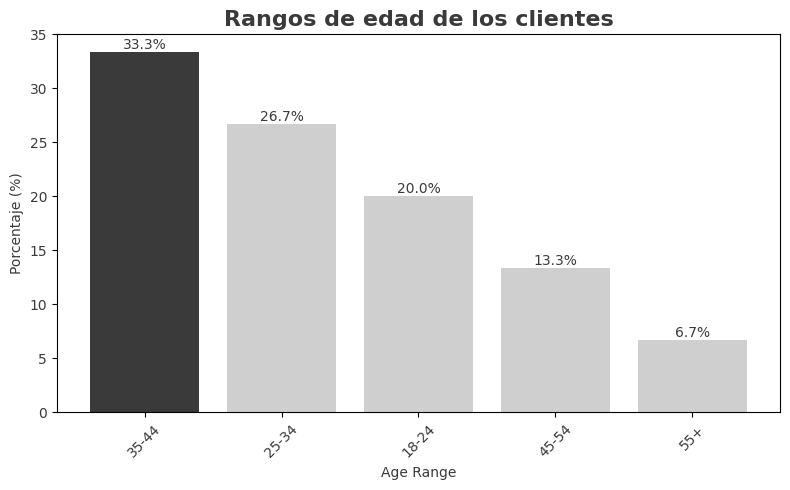

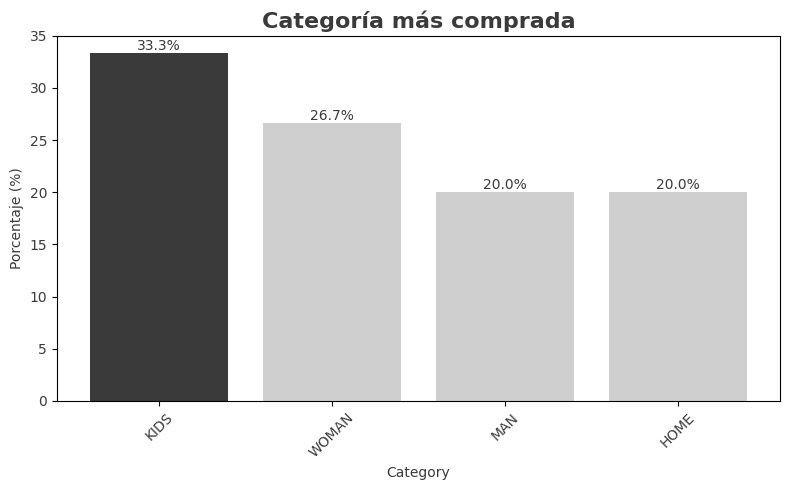

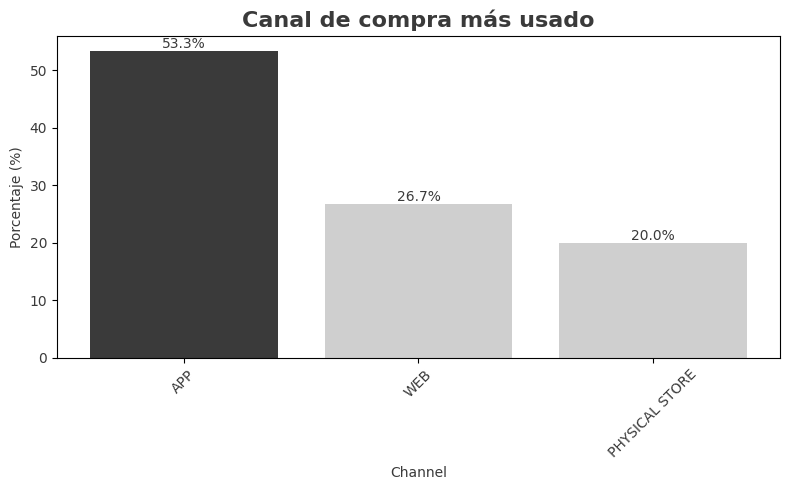

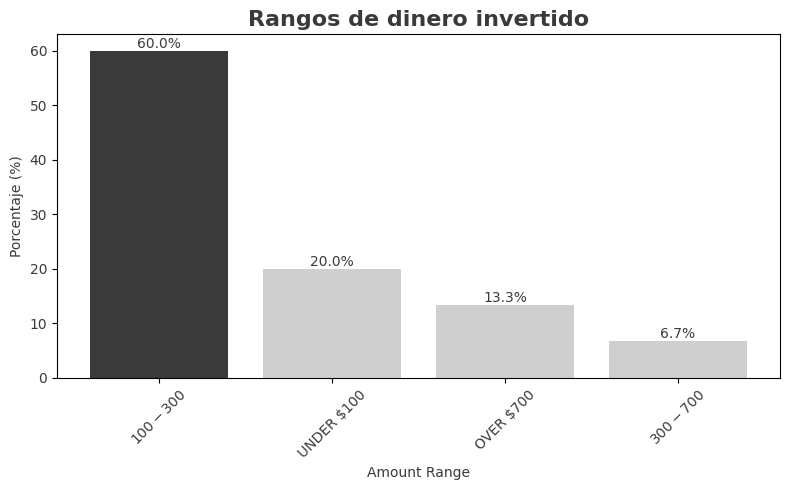

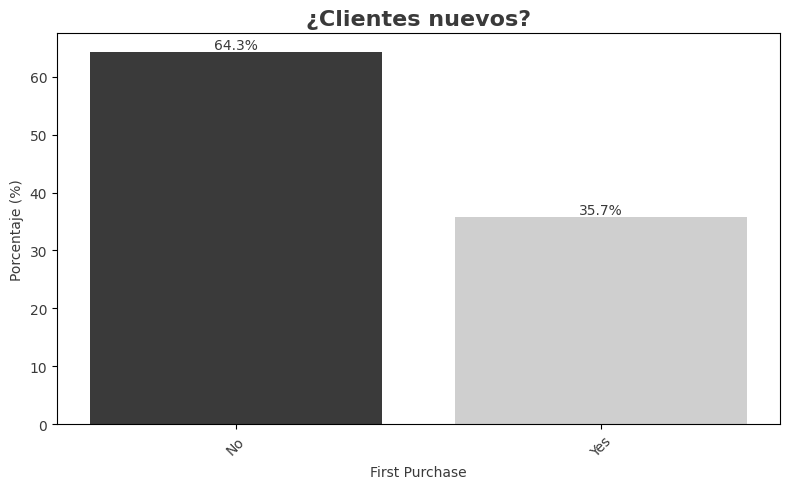

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# FUENTE ELEGANTE (ZARA STYLE)
# =========================
plt.rcParams["font.family"] = "DejaVu Sans"

df = pd.read_csv("datos_survey.csv") #========================== ACTUALIZAR RUTA

# =========================
# FUNCIÓN REUTILIZABLE
# =========================
def plot_percent_highlight(series, title, xlabel):
    pct = (series.value_counts(normalize=True) * 100)
    pct = pct.sort_values(ascending=False)

    max_idx = pct.idxmax()

    gl = "#CFCFCF"
    g = "#3A3A3A"

    colors = [g if x == max_idx else gl for x in pct.index]

    plt.figure(figsize=(8,5))
    bars = plt.bar(pct.index, pct.values, color=colors)

    for bar, value in zip(bars, pct.values):
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{value:.1f}%",
            ha="center",
            va="bottom",
            fontsize=10,
            color=g
        )

    plt.title(title, fontsize=16, fontweight="bold", color=g)
    plt.xlabel(xlabel, color=g)
    plt.ylabel("Porcentaje (%)", color=g)

    plt.xticks(rotation=45, color=g)
    plt.yticks(color=g)

    plt.tight_layout()
    plt.show()


# =========================
# AGE RANGE
# =========================
plot_percent_highlight(df["age_range"], "Rangos de edad de los clientes", "Age Range")

# =========================
# CATEGORY
# =========================
plot_percent_highlight(df["category"], "Categoría más comprada", "Category")

# =========================
# PURCHASE CHANNEL
# =========================
plot_percent_highlight(df["purchase_channel"], "Canal de compra más usado", "Channel")

# =========================
# PURCHASE AMOUNT RANGE
# =========================
plot_percent_highlight(df["purchase_amount_range"], "Rangos de dinero invertido", "Amount Range")

# =========================
# FIRST PURCHASE (YES/NO)
# =========================
plot_percent_highlight(df["first_purchase"], "¿Clientes nuevos?", "First Purchase")